Data importing and cleaning

In [ ]:
# Run once. Merge all datasets into a single file with a consistent schema. This will create 'merged.csv' in the same directory.
import pandas as pd

# Load datasets
df = pd.read_csv('datasets/Car_data.csv')
df1 = pd.read_csv('datasets/Car_details_v3.csv')
df2 = pd.read_csv('datasets/CAR_DETAILS_FROM_CAR_DEKHO.csv')

# Rename columns in df to match df2's schema
df_renamed = df.rename(columns={
    'Car_Name': 'name',
    'Year': 'year',
    'Selling_Price': 'selling_price',
    'Kms_Driven': 'km_driven',
    'Fuel_Type': 'fuel',
    'Seller_Type': 'seller_type',
    'Transmission': 'transmission',
    'Owner': 'owner'
})

# Keep only the common columns defined by df2
common_cols = ['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner']

df_renamed = df_renamed[common_cols]
df1_selected = df1[common_cols]
df2_selected = df2[common_cols]   # df2 already has exactly these columns

# Concatenate all rows
merged = pd.concat([df_renamed, df1_selected, df2_selected], ignore_index=True)

# Export to the same directory
merged.to_csv('datasets/merged.csv', index=False)

print("Dataset shape:", df.shape)
display(df.head())

✅ Merged file saved as 'datasets/merged.csv' with 11875 rows.


In [16]:
import pandas as pd
# check merged dataset
merged_df = pd.read_csv('datasets/merged.csv')
print("Dataset shape:", merged_df.shape)
display(merged_df.head())

Dataset shape: (11875, 8)


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,ritz,2014,3.35,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,42450,Diesel,Dealer,Manual,0


In [17]:
# Encode categorical text into numbers so we can calculate correlations
from sklearn.preprocessing import LabelEncoder

# Make a copy for encoding
df_encoded = merged_df.copy()

# Apply label encoding to all categorical columns
label_encoders = {}
categorical_cols = df_encoded.select_dtypes(include=['object']).columns

for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le

# Save the encoded dataset
df_encoded.to_csv('datasets/encoded.csv', index=False)

print("Dataset shape:", df_encoded.shape)
display(df_encoded.head())

Dataset shape: (11875, 8)


C:\Users\pablo\AppData\Local\Temp\ipykernel_10552\619079100.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_encoded.select_dtypes(include=['object']).columns


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,2540,2014,3.35,27000,4,0,1,0
1,2543,2013,4.75,43000,1,0,1,0
2,2519,2017,7.25,6900,4,0,1,0
3,2546,2011,2.85,5200,4,0,1,0
4,2542,2014,4.60,42450,1,0,1,0


In [18]:
#  normalize the data and shuffle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Load the encoded dataset
encoded_df = pd.read_csv('datasets/encoded.csv')

# Normalize all columns using Min-Max scaling
scaler = MinMaxScaler()
normalized_data = scaler.fit_transform(encoded_df)

# Convert back to DataFrame with original column names
normalized_df = pd.DataFrame(normalized_data, columns=encoded_df.columns)

# Save the full normalized dataset
normalized_df.to_csv('datasets/normalized.csv', index=False)

# Split into train and test sets (80% train, 20% test) with shuffling
train_df, test_df = train_test_split(normalized_df, test_size=0.2, shuffle=True, random_state=42)

# Save the splits
train_df.to_csv('datasets/train.csv', index=False)
test_df.to_csv('datasets/test.csv', index=False)


Now checking for coorelation and making the analisys of the data

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make sure the path matches your datasets folder
df = pd.read_csv('datasets/normalized.csv')


print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (11875, 8)


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,0.997252,0.837838,3.250000e-07,0.011438,1.00,0.0,1.0,0.0
1,0.998430,0.810811,4.650000e-07,0.018216,0.25,0.0,1.0,0.0
2,0.989007,0.918919,7.150000e-07,0.002923,1.00,0.0,1.0,0.0
3,0.999607,0.756757,2.750000e-07,0.002203,1.00,0.0,1.0,0.0
4,0.998037,0.837838,4.500000e-07,0.017983,0.25,0.0,1.0,0.0


In [20]:
# 1. Описание датасета (Describe the dataset)
print("Data Types and Missing Values:")
df.info()

print("\nStatistical summary:")
display(df.describe())

print("\nMissing values:")
display(df.isnull().sum())

Data Types and Missing Values:
<class 'pandas.DataFrame'>
RangeIndex: 11875 entries, 0 to 11874
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           11875 non-null  float64
 1   year           11875 non-null  float64
 2   selling_price  11875 non-null  float64
 3   km_driven      11875 non-null  float64
 4   fuel           11875 non-null  float64
 5   seller_type    11875 non-null  float64
 6   transmission   11875 non-null  float64
 7   owner          11875 non-null  float64
dtypes: float64(8)
memory usage: 742.3 KB

Statistical summary:


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
count,11875.000000,11875.000000,11875.000000,11875.000000,11875.000000,11875.000000,11875.000000,11875.000000
mean,0.512942,0.825898,0.057556,0.028719,0.602274,0.422611,0.879074,0.532980
std,0.264415,0.110853,0.072589,0.022672,0.376052,0.214118,0.326055,0.191854
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.296820,0.756757,0.022500,0.014404,0.250000,0.500000,1.000000,0.428571
50%,0.531606,0.837838,0.040000,0.025418,0.250000,0.500000,1.000000,0.428571
75%,0.687868,0.918919,0.065000,0.038128,1.000000,0.500000,1.000000,0.714286
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000



Missing values:


name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

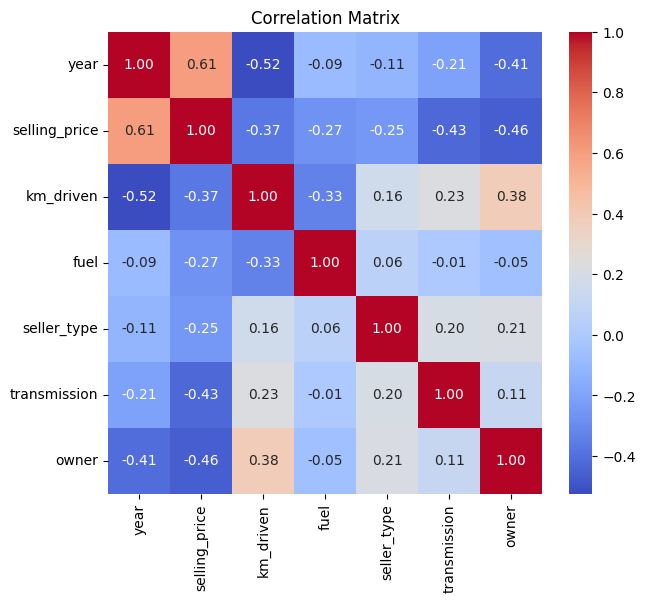

In [24]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Encode categorical text into numbers so we can calculate correlations
encoder = LabelEncoder()
categorical_cols =['name','year','selling_price','km_driven','fuel','seller_type','transmission','owner']

df_encoded = df.copy()
for col in categorical_cols:
    if col in df_encoded.columns:
        df_encoded[col] = encoder.fit_transform(df_encoded[col].astype(str))

# Plot Correlation Heatmap
plt.figure(figsize=(7, 6))

# SAFETY CHECK: Select ONLY numeric columns before calculating correlation
numeric_df = df_encoded.select_dtypes(include=[np.number])

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()